# Supervised Learning with Linear Regression

**🎯 Lesson Objectives**

**By the end of this lesson, you will be able to:**
- Understand **supervised learning** and **linear regression** in machine learning.  
- Perform **train-test splitting** for model evaluation.  
- Apply **L1 (Lasso) and L2 (Ridge) regularization** techniques.  
- Evaluate model performance using **R-squared** and **Mean Squared Error (MSE)**. 

**🎯What we will cover:**
- **Understand Supervised Learning and Linear Regression**  
  - Learn what **supervised learning** is and how it applies to regression.  
  - Understand the fundamentals of **linear regression** and its role in predicting continuous values.  


- **Prepare Data for Model Training**  
  - Perform **train-test splitting** to evaluate model performance.  
  - Understand **overfitting** and how to mitigate it using train-test validation.  


- **Compare Machine Learning and Statistical Modeling**  
  - Learn key differences between **ML and traditional statistical models**.  
  - Understand when to use statistical inference vs. predictive modeling.  


- **Apply Regularization Techniques**  
  - Understand **L1 (Lasso) and L2 (Ridge) regularization** and their impact on model complexity.  
  - Learn how **regularization** helps prevent overfitting and improves generalization.  


- **Evaluate Model Performance**  
  - Assess model accuracy using **R-squared and Mean Squared Error (MSE)**.  
  - Interpret the impact of regularization on model coefficients and predictions.  
  - Visualize model results using **scatter plots and residual analysis**.  

## **🔄 Recap: Key Elements from the Pre-Learning**  

Before learning **Supervised Learning with Linear Regression** in Machine Learning, it is important to understand some fundamental concepts. Below is an overview of key topics to grasp before diving into Supervised Learning with Linear Regression.

### **1. What is Supervised Learning?**
- **Supervised learning** is a type of machine learning where a model learns from labeled data.
- In the following sections, we will focus on two common models:
  - **Linear regression** (used for predicting continuous numbers like price or temperature).
  - **Decision trees** (used for making decisions based on conditions).


### **2. Splitting Data into Training and Testing Sets**
- We split our dataset into **two parts**:
  - **Training set** (used to teach the model).
  - **Testing set** (used to check how well the model works on new data).
- Usually, we use **80% of the data for training** and **20% for testing**.
- This technique helps us avoid **overfitting**, where a model memorizes the training data but performs poorly on new data.


### **3. What is Linear Regression?**
- Linear regression is a statistical method used to **model the relationship between a dependent variable and one or more independent variables**.
- It helps in **predicting an outcome** (e.g., house price) based on numerical inputs (e.g., size and location).
- **Examples of Linear Regression Applications**:
  - **Finance**: Predicting stock prices based on past data.
  - **Healthcare**: Predicting a patient's health risk based on their age and lifestyle.
  - **Marketing**: Understanding how advertising affects sales.
  - **Education**: Predicting student grades based on study time.


### **4. How Does Linear Regression Work?**  
- Linear regression **finds the best-fitting line** that fits the data points. 
- The equation of this line is typically:  \[  y = wx + b  \]
- This line helps predict future values.
- **Key Problems**:
  - **Underfitting (high bias)**: The model is too simple and doesn’t capture the pattern in the data.
  - **Overfitting (high variance)**: The model is too complex and fits noise instead of the real pattern.


### **5. How to Measure Prediction Errors**
- We need to check how **accurate** our model is. Some common ways to measure errors:
  - **Mean Squared Error (MSE)**: Measures how far predictions are from actual values.
  - **Root Mean Squared Error (RMSE)**: Similar to MSE but easier to understand because it’s in the same unit as the data.
  - **Mean Absolute Error (MAE)**: Shows the average error without squaring it.
  - **R² (R-Squared)**: Measures how well the model explains the data.


### **6. Types of Linear Regression**  
- **Ordinary Least Squares (OLS) Regression** (Traditional Standard Method):  
  - The most commonly used approach for linear regression.  
  - Finds the **best-fitting line** by minimising the difference between actual and predicted values.


- **Regularized Regression**: Helps control model complexity to prevent overfitting.  
  - **Ridge Regression**: Reduces the impact of large coefficients to improve generalisation.  
  - **Lasso Regression**: Selects only the most important variables by shrinking less important ones to zero.

---

# 🚀 Linear regression

*Linear regression* is a statistical technique to model relationships between *scalar respsonse* and one or more *explanatory variables*. 

It has two primary purposes:
- *Hypothesis testing*: Testing for **relationships** between explanatory variables and response, given a data sample
- *Forecasting*: Making **predictions** about the value of the response for new values of the explanatory variables

The *forecasting* can also be thought of as supervised learning:
- Predict the value of a continuous *target*
- Using one or more input *features*
- Assumes the relationships between the input features and target are linear

#### 💡 Knowledge Check 1

What does **Linear Regression** assume about the data?

- **A)** The relationship between input features and the target variable is linear.
- **B)** The model can only be used for classification problems.
- **C)** Linear regression requires only one input feature to predict the target. 
- **D)** Predictions are made by calculating the median of the dataset.

In [1]:
#put your answer below


---

# 🚀 Machine Learning vs Statistical Modelling

Machine learning and statistical modelling have significant overlaps but differ in focus.  

- **Statistical Modelling** prioritises understanding *how* the model works.  
  - Example: Conducting significance tests on model parameters to interpret relationships.  


- **Machine Learning** focuses on *how well* the model predicts unseen data.  
  - Example: Optimising a model to achieve the best possible accuracy in predicting house prices.  

**Note:** This is a simplification— in practice, the differences can be more subtle!

## Machine Learning vs Statistical Modelling: Vocabulary

As the two fields have developed somewhat independently, they use different terminology for overlapping concepts. The following table highlights some of the key equivalents:  

| **Statistical Modelling**                | **Machine Learning**  |  
|-------------------------------------------|----------------------|  
| Independent variable / Explanatory variable | Input feature       |  
| Dependent variable / Response             | Target / Label /Output feature      |  
| Estimate a model                          | Train / Fit a model |  
| Parameters (Coefficients & Intercept)     | Weights & Bias |  
| Forecasting                               | Prediction          |

---

# 🚀 Train-Test Split  

In machine learning, we test a model on *unseen data* using **train-test split** (also called *holdout validation*).  

- **Training set** – Used to train the model.  
- **Test set** – Used to evaluate its performance on new unseen data.  

A common split is **80% training, 20% testing**. This prevents **overfitting**, ensuring the model generalises well to unseen data. The test set estimates the **generalisation error**, indicating real-world performance.

## Example: Train-Test Split

- Let's look at an example of creating a training and test set split for a linear regression model.
- First, let's generate some data where true data generation function is known.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define the true underlying relationship between x and y
def true_function(x):
    return 2 * x + 1

# Generate some noisy data around the true function
np.random.seed(0)
n_samples = 50
X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.randn(n_samples) * 0.3


We create a 90% traning 10% test set split with the `train_test_split` function from `sklearn`:

In [3]:
# we use a 90,10 split
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Total number of observations for each split created
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((45,), (5,), (45,), (5,))

- Here we can see the number of observations in the train and test set for both the target and explanatory variables.

**We can examine the data and the train-test set splits we created using a scatter plot. In the plot below:**

- The training set observations are represented by blue dots.
- The test set observations are represented by green dots.
- The true data generation function (which is often unknown in real-life applications) is represented by a red line.

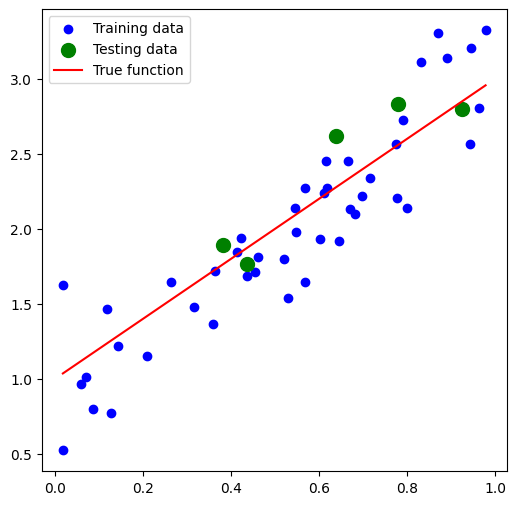

In [4]:
# Plot the true function, the training data, and the test data
plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Testing data', s=100)
plt.plot(X, true_function(X), color='red', label='True function')
plt.legend()
plt.show()

In this code, we utilize the `LinearRegression` module from `sklearn` to create a linear regression model.

- By invoking the `.fit()` method, the optimal parameters for the linear model are estimated.

- It's important to keep in mind that we only train the model on the training data (`X_train` and `y_train`) and not on the test data. This ensures that the model's performance on the test data is a fair measure of its generalization ability.

#### 💡 Knowledge Check 2

Why is it important to use a **Train-Test Split** when building a machine learning model?

*Select two that apply*

- **A)** To train the model on part of the data and leave some aside for testing.
- **B)** To test the model on data it has already seen during training.
- **C)** To check how well the model performs on unseen data.
- **D)** To make sure the model memorizes the training data.

In [5]:
#put your answer below


---

# 🚀 Creating a Linear Regression Model

- y = wx + b

In [6]:
# Import the linear regression from sklearn & create instance of the model.
from sklearn.linear_model import LinearRegression

# Fit a linear regression model to the training data
model = LinearRegression().fit(X_train.reshape(-1, 1), y_train)

In [7]:
model.coef_

array([2.23234716])

In [8]:
model.intercept_

0.8071272035803565

We can assess the performance of the linear regression model on both the training and test sets.

Calling the `.score()` method provides us with the R-squared score for the training set, which is a measure of how well the model fits the training data.

In [9]:
model.score(X_train.reshape(-1, 1), y_train)

0.8354045430505105

Let's see what the R squared score is for the test set:

In [10]:
model.score(X_test.reshape(-1, 1), y_test)

0.724628541485133

There seems to be a noticeable discrepancy between the R-squared scores of the training and test sets.

To gain a deeper understanding, we can visualual the differences between the training and test set predictions.

In [11]:
# Get the predictions for both the train and test set
y_test_pred = model.predict(X_test.reshape(-1, 1))
y_train_pred = model.predict(X_train.reshape(-1, 1))

The graph below provides shows:

* The red line represents the actual underlying data function.
* The blue dots correspond to the training data, while the green dots represent the testing data.
* The purple and orange lines depict the model's predictions for the training and testing sets, respectively.

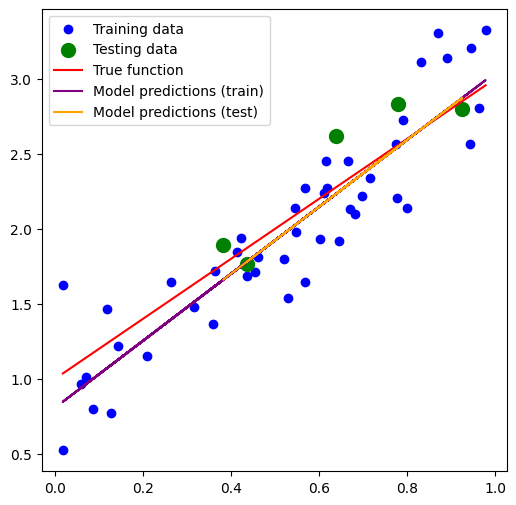

In [12]:
# Plot the true function, the training data, and the model's predictions
plt.figure(figsize=(6, 6))

plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', label='Testing data', s=100)

plt.plot(X, true_function(X), color='red', label='True function')
plt.plot(X_train, y_train_pred, color='purple', label='Model predictions (train)')
plt.plot(X_test, y_test_pred, color='orange', label='Model predictions (test)')
plt.legend()
plt.show()

---


# 🚀 Bias-variance tradeoff

The bias-variance tradeoff comes into play when we compare the purple and orange lines to the red line. 

The bias-variance tradeoff is a fundamental concept in machine learning that refers to the relationship between a model's complexity and its ability to generalize to new, unseen data. The tradeoff involves two types of errors: bias and variance.

* **What is the bias error** - this is the error that arises from erroneous assumptions in the ML algorithm. High bias can cause an algorithm to miss the relevant relations between features and target outputs (**underfitting**)

* **What is the variance error** - this the error that arises from sensitivity to small fluctuations in the training set. High variance may result from an algorithm modeling the random noise in the training data (**overfitting**)

From our example above:

- If the model is underfitting the data (i.e., has high bias), then the purple and orange lines will be close to each other and far from the actual function (i.e., the red line). 

- On the other hand, if the model is overfitting the data (i.e., has high variance), then the purple and orange lines will be very close to the training data (i.e., the blue dots) but far from the true function and test data (i.e., the green dots).


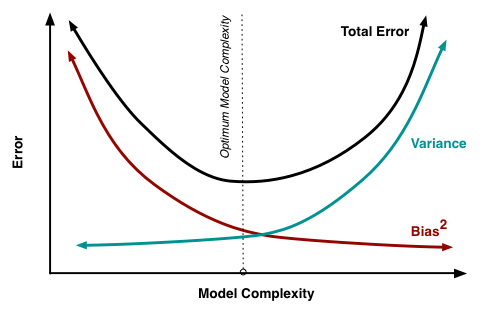

#### How to achieve a balance between bias and variance for linear regression

We can manipulate the bias-variance tradeoff by changing the complexity of the model. 


- In this example, we used a simple linear regression model with one input variable (X). 
- To reduce bias, we could try using a more complex model with more input variables or higher-order terms. 
- To reduce variance, we could try using a simpler model with fewer input variables or regularisation techniques. 

The key is to find the right balance between bias and variance that minimizes the model's overall error.

#### 💡 Knowledge Check 3

What is the **primary goal** when managing the ****Bias/Variance tradeoff** in machine learning?

- **A)** To increase complexity and remove bias entirely.
- **B)** To memorise the training data for higher accuracy.
- **C)** To balance bias and variance to reduce total error.
- **D)** To choose a model with either high bias or high variance.

In [13]:
#put your answer below


### Mean Squared Error(MSE)

In linear regression, the mean squared error (MSE) is a common metric used to evaluate how well a model performs on a set of test data that it has not seen during training. 

The MSE is calculated as the average of the squared differences between the predicted values and the actual values of the test data.

#### MSE: Definition

- Consider a linear regression model that you have trained on a set of training data with input features $X$ and output variable $y$. 

- Let's denote the predicted output of the model for a new input value $x_i$ as $\hat{y}_i$. 

- For a test set with $n$ data points, the MSE is defined as:

$$MSE = \frac{1}{n} \sum(y_i - \hat{y}_i)^2$$

where $\sum$ denotes the sum from $i=1$ to $n$.

#### Lower MSE

- A lower MSE indicates better performance of the model on the test set: The predicted values are closer to the groundtruth values.

It is important to note that the MSE is not the only metric that can be used to evaluate the performance of a linear regression model. Other metrics like root mean squared error (RMSE), mean absolute error (MAE), and coefficient of determination ($R^2$) can be used and this depends on the specific problem and requirements.

---


# 🚀 Regularisation  

Regularisation, also known as **penalised regression**, is a technique used to reduce high variance and prevent overfitting in machine learning models.

Regularisation helps improve the **generalisation** of models by preventing them from fitting too closely to the training data.

#### Types of Regularisation: 
- **L1 Regularisation (Lasso Regression)** – Shrinks some coefficients to zero, effectively performing feature selection.  
- **L2 Regularisation (Ridge Regression)** – Penalises large coefficients but does not shrink them to zero, reducing model complexity without eliminating features. 

## 🔷 Ridge Regression

Ridge regression is a regularized linear regression technique that is used to address the problem of overfitting in high-dimensional datasets. 

It is a variant of linear regression that adds a penalty term to the cost function, which limits the size of the regression coefficients.

#### Why use Ridge regression over traditional linear regression?
- In traditional linear regression, the objective is to find the values of the regression coefficients that minimize the sum of squared errors between the predicted values and the actual values. 

- However, when the number of features in the dataset is large, traditional linear regression can lead to overfitting, e.e. the model performs well on the training data but poorly on new, unseen data.

Ridge regression addresses this problem by adding a regularization term to the cost function. 

- The regularization term is a penalty term that is proportional to the sum of squares of the regression coefficients. 
- The effect of the regularization term is to shrink the values of the regression coefficients towards zero, which reduces their impact on the predictions.

The cost function for ridge regression is given by:

$$\text{Cost} = \sum_{i=1}^{n} (y_i - \hat{y}i)^2 + \lambda\sum_{j=1}^p\beta_j^2 $$

Where:

- $y_i$ is the actual value of the dependent variable for the i-th observation
- $\hat{y}_i$ is the predicted value of the dependent variable for the i-th observation
- $n$ is the number of observations
- $p$ is the number of features
- $\beta_j$ is the regression coefficient for the j-th feature
- $\lambda$ is the regularization parameter, which controls the strength of the penalty term

This is called **L2 penalty function** because the function is the square of the magnitude of coefficients in the model.

#### What is the purpose of the $\lambda$ term?

- The regularization parameter $\lambda$ is a hyperparameter that is typically chosen using cross-validation. 
- A higher value of $\lambda$ results in more regularization and smaller coefficients, which reduces the model's complexity and the risk of overfitting. 
- A lower value of $\lambda$ results in less regularization and larger coefficients, which increases the model's complexity and the risk of overfitting.


## 🔷 Lasso Regression (least absolute shrinkage and selection operator)

Lasso regression is a regularized linear regression technique that is used to select a subset of features in high-dimensional datasets. 

It is similar to ridge regression. It adds a penalty term to the cost function to prevent overfitting, but the penalty term is different, and it has the additional property of inducing sparsity in the solution.

Lasso regression addresses the same problem as Ridge regression by adding a regularization term to the cost function. 

- The regularization term is a penalty term that is proportional to the absolute values of the regression coefficients. 
- The effect of the regularization term is to shrink the values of some of the regression coefficients towards zero, which reduces their impact on the predictions and **can lead to some coefficients being zero**. 
- This has the effect of inducing sparsity in the solution, meaning that only a subset of the features are selected in the final model.

The cost function for lasso regression is given by:

$$\text{Cost} = \sum_{i=1}^{n} (y_i - \hat{y}i)^2 + \lambda\sum_{j=1}^p|\beta_j|$$

Where:

- $y_i$ is the actual value of the dependent variable for the i-th observation
- $\hat{y}_i$ is the predicted value of the dependent variable for the i-th observation
- $n$ is the number of observations
- $p$ is the number of features
- $\beta_j$ is the regression coefficient for the j-th feature
- $\lambda$ is the regularization parameter, which controls the strength of the penalty term

#### When to use Lasso regression?

- Lasso regression is particularly effective when there are many features in the dataset, and only a subset of the features is expected to be important for the model's performance.
- Lasso regression can also be used for feature selection. By shrinking the coefficients of unimportant features to zero, Lasso effectively removes them from the model, resulting in a more efficient and streamlined representation of the data.

#### 💡 Knowledge Check 4

How could we `tune` our **Lasso** and **Ridge** models to potentially improve performance?

In [14]:
#put your answer below


---


# 🚀 Example: Comparing Linear, Ridge, and Lasso Regression in `sklearn`

In this example, we'll apply Linear Regression, Ridge Regression, and Lasso Regression on the same dataset and evaluate their performance.  

---

### **The Dataset: Diabetes Dataset**  

This dataset contains **442 samples** with **10 numerical features**, including:  
- **Features:** Age, sex, body mass index, average blood pressure, and six blood serum measurements.  
- **Target Label:** A quantitative measure of diabetes progression one year after baseline.  

**Feature Scaling:**  
- All **10 features** have been **mean-centered and standardised**, so that the sum of squares of each column equals **1**.  

📌 **Source:** [Diabetes Dataset](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html)  

---

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

Let's have a look at the explanatory variables and the target variable:

In [16]:
# Get some data
diabetes = load_diabetes()

# create a pandas dataframe with the data
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

# add target variable to dataframe
df['target'] = diabetes.target

# display the first 5 rows of the dataframe
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


We create a training (80%) and test (20%) set split:.

In [17]:
# Split the dataset into training(80%) and testing(20%) sets
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.2, random_state=42)


In [18]:
# Total number of observations for each split created
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((353, 10), (89, 10), (353,), (89,))

Fit all three models using the method `.fit()`:

In [19]:
# Create a ridge regression object with alpha=0.5
linear = LinearRegression()
ridge = Ridge(alpha=0.5)
lasso = Lasso(alpha=0.5)

# Fit the model using the training data
linear.fit(X_train,y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train,y_train)

Lasso(alpha=0.5)

Let's have a look at the coeffcients for each model:

In [20]:
# print(linear.coef_)
# print(ridge.coef_)
# print(lasso.coef_)

In [21]:
# Create a DataFrame to compare coefficients of Linear, Ridge, and Lasso Regression
pd.DataFrame([linear.coef_, ridge.coef_, lasso.coef_],
             index=['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
             columns=diabetes.feature_names)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
Linear Regression,37.904021,-241.964362,542.428759,347.703844,-931.488846,518.062277,163.419983,275.317902,736.198859,48.670657
Ridge Regression,45.642910,-123.523121,376.151474,248.410719,-26.899113,-59.716887,-172.549216,131.895877,289.160153,112.146218
Lasso Regression,0.000000,-0.000000,513.587467,165.497563,-0.000000,-0.000000,-72.683391,0.000000,354.650101,0.000000


Let's visualise the difference between the coefficients of each of the three methods: 

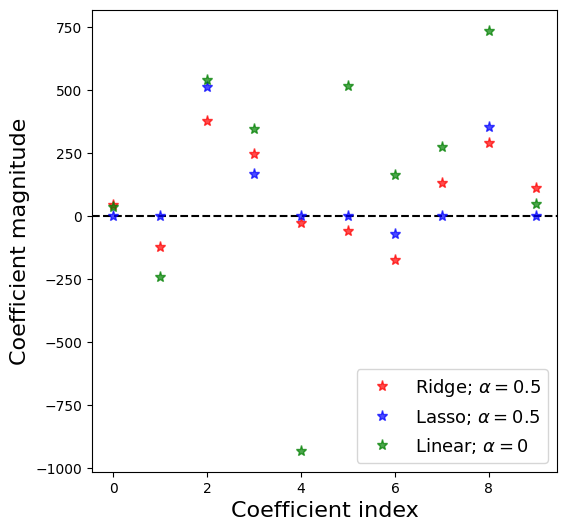

In [22]:
# Plot the coefficients
plt.figure(figsize=(6, 6))
plt.plot(ridge.coef_, alpha=0.7, linestyle='none', marker='*', markersize=8, color='red', label=r'Ridge; $\alpha = 0.5$', zorder=7)
plt.plot(lasso.coef_, alpha=0.7, linestyle='none', marker='*', markersize=8, color='blue', label=r'Lasso; $\alpha = 0.5$', zorder=7)
plt.plot(linear.coef_, alpha=0.7, linestyle='none', marker='*', markersize=8, color='green', label=r'Linear; $\alpha = 0$', zorder=7)
plt.axhline(y=0.5, color='k', linestyle='--')
plt.xlabel('Coefficient index', fontsize=16)
plt.ylabel('Coefficient magnitude', fontsize=16)
plt.legend(fontsize=13, loc=4)
plt.show()

Ridge regression shrinks coefficients to be close to zero but Lasso regression shrinks the coefficients all the way to zero.

Let's calculate the Mean Squared Error for each method:

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict the target values for the test data
y_pred_lr = linear.predict(X_test)
y_pred_ridge = ridge.predict(X_test)
y_pred_lasso = lasso.predict(X_test)

# Calculate the mean squared error of the predictions
mse_lr = mean_squared_error(y_test, y_pred_lr)
print("Mean Squared Error for Linear Regression: ", mse_lr)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print("Mean Squared Error for Ridge Regression: ", mse_ridge)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print("Mean Squared Error for Lasso Regression: ", mse_lasso)

Mean Squared Error for Linear Regression:  2900.193628493482
Mean Squared Error for Ridge Regression:  2917.176593478921
Mean Squared Error for Lasso Regression:  2945.148879042492


In [24]:
# Calculate R-squared (coefficient of determination)
r2_lr = r2_score(y_test, y_pred_lr)
print("R-squared for Linear Regression: ", r2_lr)
r2_ridge = r2_score(y_test, y_pred_ridge)
print("R-squared for Ridge Regression: ", r2_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)
print("R-squared for Lasso Regression: ", r2_lasso)

R-squared for Linear Regression:  0.4526027629719195
R-squared for Ridge Regression:  0.4493973121295206
R-squared for Lasso Regression:  0.44411768125231843


### **🔑 Summary / Key Takeaways**
By completing this lesson, you should now be able to:


- ✅ Understand **supervised learning** and its role in regression.  
- ✅ Explain **linear regression** and its purpose in machine learning.  
- ✅ Perform **train-test splitting** for model evaluation.  
- ✅ Compare **machine learning vs. statistical modeling** approaches.  
- ✅ Apply **L1 (Lasso) and L2 (Ridge) regularization** techniques.  
- ✅ Evaluate models using **R-squared and Mean Squared Error (MSE)**.  


### **📝 Next Steps:**  

- **Complete the practical lab work**: Open and work through the following workbook:`ssupervised-learning-with-linear-regression-workbook.ipynb`. 